Dataset cargado: (31815, 22)
              precision    recall  f1-score   support

        High       0.52      0.53      0.52      1874
         Low       0.63      0.71      0.67      2891
      Medium       0.37      0.26      0.30      1598

    accuracy                           0.55      6363
   macro avg       0.50      0.50      0.50      6363
weighted avg       0.53      0.55      0.53      6363

    Hour  Avg_Risk
0      0  0.907148
1      1  0.903632
2      2  0.911442
3      3  0.893130
4      4  0.900688
5      5  0.836611
6      6  0.828508
7      7  0.822305
8      8  0.823838
9      9  0.825702
10    10  0.816465
11    11  0.817293
12    12  0.792581
13    13  0.790455
14    14  0.779018
15    15  0.768072
16    16  0.757121
17    17  0.763569
18    18  0.786350
19    19  0.806380
20    20  0.850074
21    21  0.881443
22    22  0.907489
23    23  0.901975


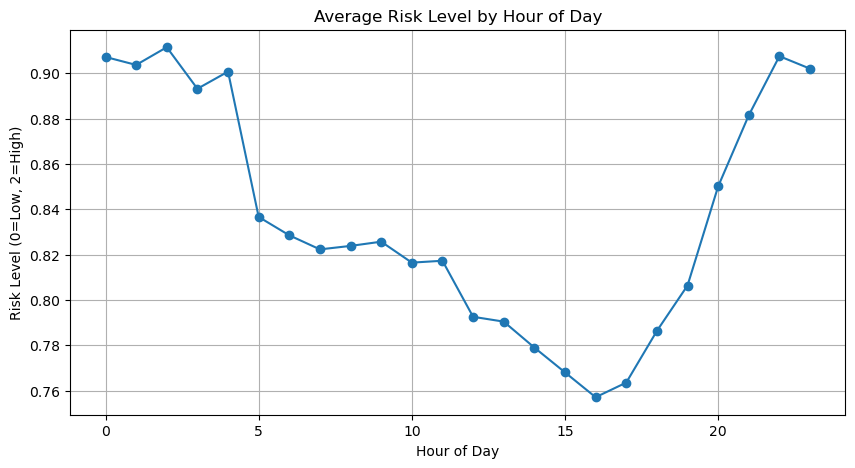

Predicted risk for example: Low


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

# ===========================
# 1. Cargar dataset limpio
# ===========================
df = pd.read_csv("../data/clean_data.csv")
print("Dataset cargado:", df.shape)

# ===========================
# 2. Variables derivadas (si no están)
# ===========================
if 'temp_wind' not in df.columns:
    df['temp_wind'] = df['TEMP'] * df['WSPM']

if 'humidity_proxy' not in df.columns:
    df['humidity_proxy'] = df['DEWP'] / (df['TEMP'] + 1e-5)

if 'rush_hour' not in df.columns:
    df['rush_hour'] = df['hour'].apply(lambda x: 1 if x in [7,8,9,18,19,20] else 0)

# ===========================
# 3. Preparar datos para el modelo
# ===========================
features = ['TEMP','WSPM','DEWP','temp_wind','humidity_proxy','rush_hour']
X = df[features]
y = df['risk']

# ===========================
# 4. Dividir en train/test
# ===========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===========================
# 5. Entrenar modelo
# ===========================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Guardar modelo
joblib.dump(model, "../data/model.pkl")

# ===========================
# 6. Evaluar modelo
# ===========================
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# ===========================
# 7. Tabla de riesgo por hora
# ===========================
df['risk_num'] = df['risk'].map({'Low':0,'Medium':1,'High':2})
hourly_risk = df.groupby('hour')['risk_num'].mean()
hourly_table = pd.DataFrame({'Hour':hourly_risk.index, 'Avg_Risk':hourly_risk.values})
print(hourly_table)

# ===========================
# 8. Gráfica de riesgo por hora
# ===========================
plt.figure(figsize=(10,5))
plt.plot(hourly_risk.index, hourly_risk.values, marker='o')
plt.title("Average Risk Level by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Risk Level (0=Low, 2=High)")
plt.grid()
plt.show()

# ===========================
# 9. Ejemplo de predicción para hora específica
# ===========================
test_example = pd.DataFrame([{
    'TEMP': 30,
    'WSPM': 1.5,
    'DEWP': 20,
    'temp_wind': 30*1.5,
    'humidity_proxy': 20/(30+1e-5),
    'rush_hour': 1
}])

# Ajustar columnas (por si hay dummy variables en X)
test_example = test_example.reindex(columns=X.columns, fill_value=0)

predicted_risk = model.predict(test_example)
print("Predicted risk for example:", predicted_risk[0])